In [1]:
import cv2
from pathlib import Path
import matplotlib.pyplot as plt
import dlib

In [2]:
BASE_DIR = Path.cwd().parent

caminho_imagem = BASE_DIR / "data" / "Images"
classifier = BASE_DIR / "data" / "Cascades"
pessos_cnn = BASE_DIR / "data" / "Weights"

In [3]:
imagem = cv2.imread(str(f"{caminho_imagem}/people3.jpg"))

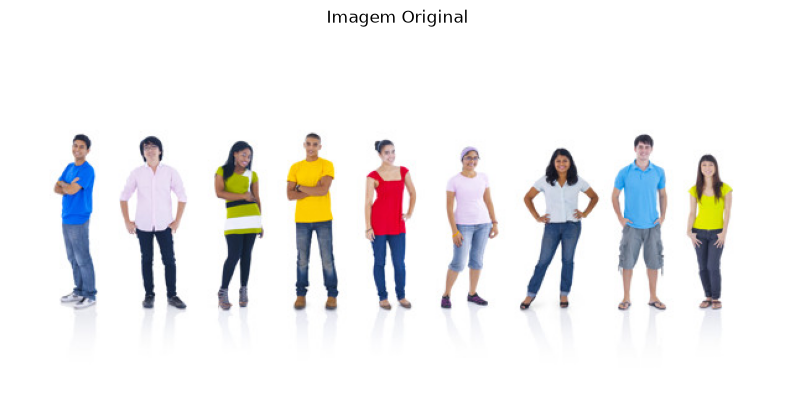

In [4]:
plt.figure(figsize=(10,10))
plt.title('Imagem Original')
imgRGB = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)
plt.imshow(imgRGB)
plt.axis('off')
plt.show()

## haarcascade

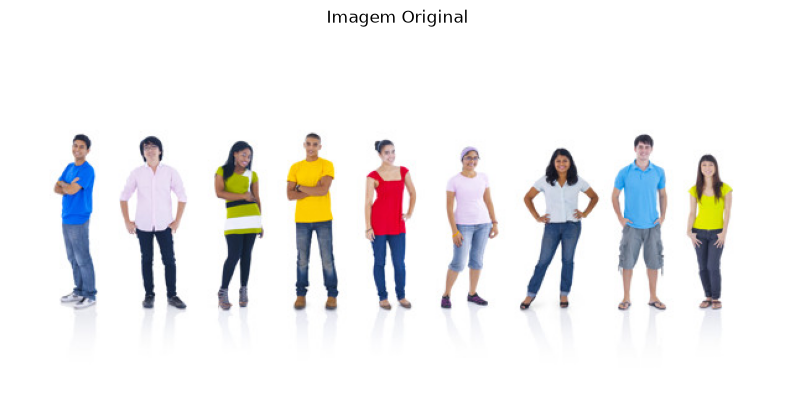

In [5]:
detector_haarcascade = cv2.CascadeClassifier(str(f"{classifier}/haarcascade_frontalface_default.xml"))
imagem_pessoa = cv2.imread(str(f"{caminho_imagem}/people3.jpg"))
imagem_pessoa_cinza = cv2.cvtColor(imagem_pessoa, cv2.COLOR_BGR2GRAY)
imagem_pessoa_cinza = cv2.cvtColor(imagem_pessoa_cinza, cv2.COLOR_BGR2RGB)
deteccao_carros = detector_haarcascade.detectMultiScale(imagem_pessoa_cinza, scaleFactor=1.10)
for (x, y, w, h) in deteccao_carros:
    cv2.rectangle(imagem_pessoa, (x, y), (x + w, y + h), (0,255,0), 1)
plt.figure(figsize=(10,10))
plt.title('Imagem Original')
imagem_pessoa = cv2.cvtColor(imagem_pessoa, cv2.COLOR_BGR2RGB)
plt.imshow(imagem_pessoa)
plt.axis('off')
plt.show()

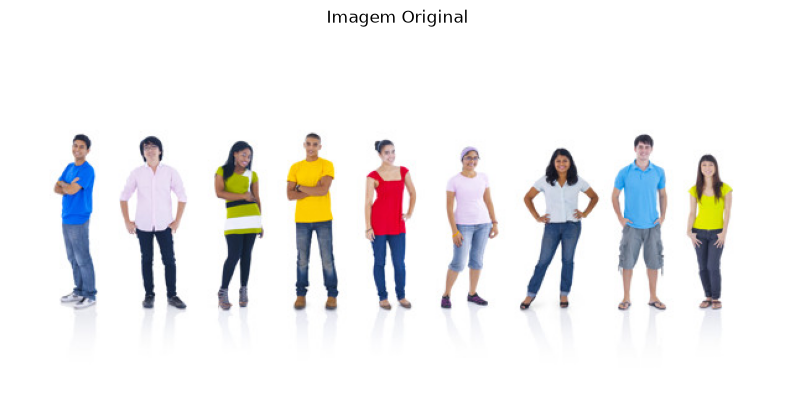

In [6]:
detector_face_hog = dlib.get_frontal_face_detector()
deteccoes = detector_face_hog(imagem_pessoa, 2)
for face in deteccoes:
    l, t, r, b = face.left(), face.top(), face.right(), face.bottom()
    cv2.rectangle(imagem_pessoa, (l, t), (r, b), (0, 255, 0), 2)
plt.figure(figsize=(10,10))
plt.title('Imagem Original')
plt.imshow(imagem_pessoa)
plt.axis('off')
plt.show()

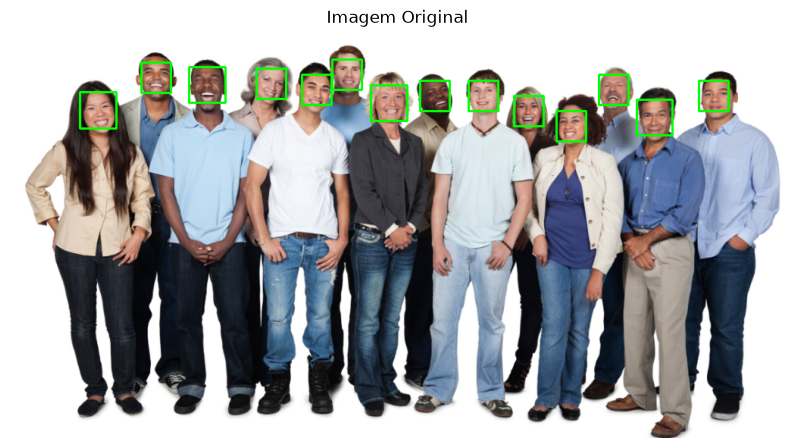

In [7]:
detector_face_cnn = dlib.cnn_face_detection_model_v1(str(f"{pessos_cnn}/mmod_human_face_detector.dat"))
imagem_pessoa = cv2.imread(str(f"{caminho_imagem}/people2.jpg"))
deteccoes = detector_face_cnn(imagem_pessoa, 1)
for face in deteccoes:
    l, t, r, b, c = face.rect.left(), face.rect.top(), face.rect.right(), face.rect.bottom(), face.confidence
    cv2.rectangle(imagem_pessoa, (l, t), (r, b), (0, 255, 0), 2)
plt.figure(figsize=(10,10))
plt.title('Imagem Original')
imagem_pessoa = cv2.cvtColor(imagem_pessoa, cv2.COLOR_BGR2RGB)
plt.imshow(imagem_pessoa)
plt.axis('off')
plt.show()